In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import joblib

In [2]:
df=pd.read_csv("student_marks_prediction.csv")
df

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Final Exam Score
0,S00001,12.5,75.3,75.0,Yes,Master,68.95
1,S00002,9.3,95.3,60.6,No,High School,61.46
2,S00003,13.2,75.3,64.0,No,Associate,62.69
3,S00004,17.6,76.8,62.4,Yes,Bachelor,66.92
4,S00005,8.8,89.3,72.7,No,Master,63.64
...,...,...,...,...,...,...,...
39995,S39996,15.6,93.8,51.4,Yes,Master,61.60
39996,S39997,11.3,66.4,64.2,No,Doctorate,55.48
39997,S39998,13.1,65.6,38.1,No,Bachelor,48.33
39998,S39999,14.1,74.9,65.2,Yes,Master,62.30


In [3]:
df.isnull().sum()

Student ID                                        0
Study Hours per Week                              0
Attendance Rate                                   0
Previous Grades                                   0
Participation in Extracurricular Activities    2000
Parent Education Level                         2000
Final Exam Score                                  0
dtype: int64

In [5]:
df=df.drop_duplicates()

In [8]:
df["Participation in Extracurricular Activities"]=df["Participation in Extracurricular Activities"].fillna(
    df["Participation in Extracurricular Activities"].mode()[0])
df["Parent Education Level"]=df["Parent Education Level"].fillna(
    df["Parent Education Level"].mode()[0])

In [9]:
df.isnull().sum()

Student ID                                     0
Study Hours per Week                           0
Attendance Rate                                0
Previous Grades                                0
Participation in Extracurricular Activities    0
Parent Education Level                         0
Final Exam Score                               0
dtype: int64

In [10]:
df["Participation in Extracurricular Activities"]=df["Participation in Extracurricular Activities"].map(
    {"Yes":1,"No":0})

df["Parent Education Level"]=df["Parent Education Level"].map(
    {"High School":0,"Associate":1,"Bachelor":2,"Master":3,"Doctorate":4})

In [13]:
df=df.drop("Student ID",axis=1)

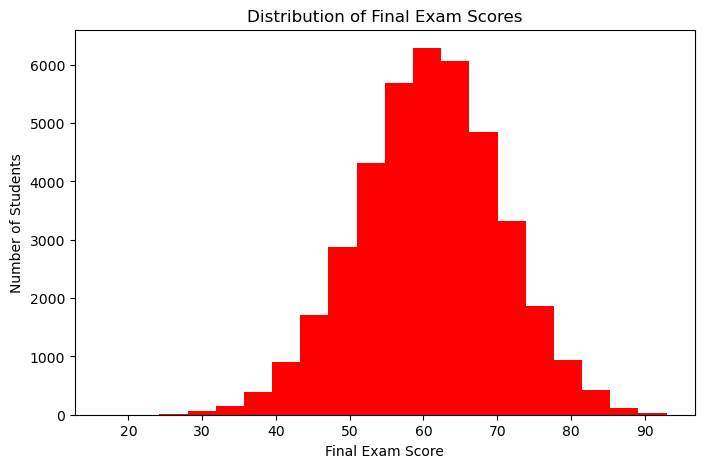

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["Final Exam Score"],bins=20,color='red')
plt.xlabel("Final Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Exam Scores")
plt.show()

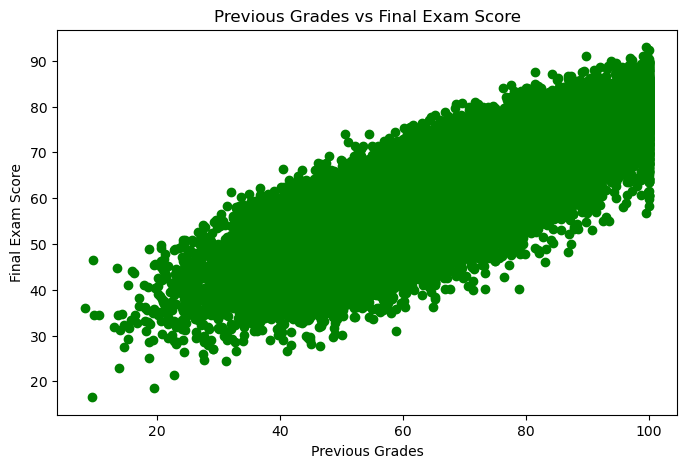

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df["Previous Grades"],df["Final Exam Score"],color='green')
plt.xlabel("Previous Grades")
plt.ylabel("Final Exam Score")
plt.title("Previous Grades vs Final Exam Score")
plt.show()

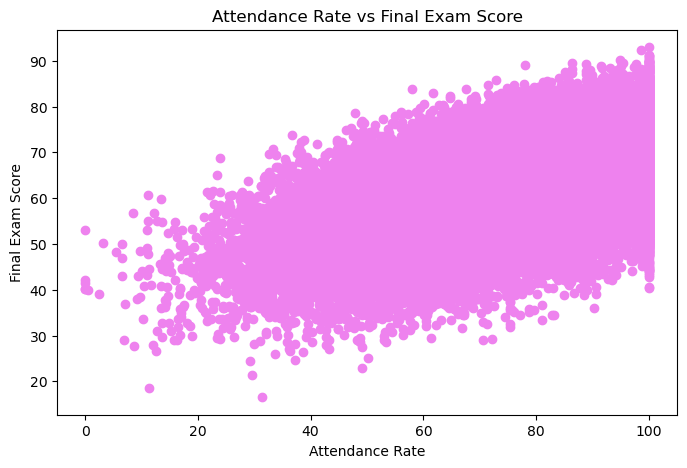

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df["Attendance Rate"],df["Final Exam Score"],color='violet')
plt.xlabel("Attendance Rate")
plt.ylabel("Final Exam Score")
plt.title("Attendance Rate vs Final Exam Score")
plt.show()

In [18]:
X=df.drop("Final Exam Score",axis=1)
y=df["Final Exam Score"]

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred=model.predict(X_test)

In [22]:
r2=r2_score(y_test,y_pred)
print("R2 Score Percentage:",r2*100,"%")

R2 Score Percentage: 95.65003079444526 %


In [23]:
mse=mean_squared_error(y_test,y_pred)
print("Mean Squared Error:",mse)

Mean Squared Error: 4.167481723276983


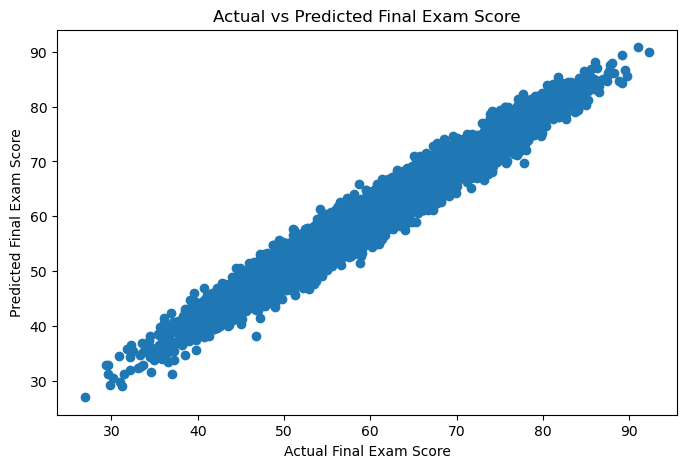

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Final Exam Score")
plt.ylabel("Predicted Final Exam Score")
plt.title("Actual vs Predicted Final Exam Score")
plt.show()

In [27]:
joblib.dump(model,"student_final_score_model.pkl")
print("Model saved successfully!")

Model saved successfully!
